# 07 — Comparison

**Goal:** gather results from every notebook (baseline, GA, PSO, GWO, WOA) and
compare them side by side on accuracy, number of features selected, and runtime,
plus convergence behavior.

Run notebooks `01` through `06` at least once before running this one — it reads
their saved outputs from `../results/`.

In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocessing import load_processed_data
from utils.plotting import (
    plot_convergence,
    plot_feature_counts,
    plot_runtime_comparison,
    plot_confusion_matrices,
    plot_metric_comparison,
)
from utils.metrics import evaluate_subset, get_confusion_matrix

## 1. Load all saved results

In [3]:
import os

results_dir = "../results"

baseline_df = pd.read_csv(os.path.join(results_dir, "baseline_results.csv"))

optimizer_frames = []
for algo in ["ga", "pso", "gwo", "woa"]:
    path = os.path.join(results_dir, f"{algo}_results.csv")
    if os.path.exists(path):
        optimizer_frames.append(pd.read_csv(path))
    else:
        print(f"Warning: {path} not found — run notebook for {algo.upper()} first.")

all_results = pd.concat([baseline_df] + optimizer_frames, ignore_index=True)
all_results

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,Baseline (SVM),0.982456,0.986111,0.986111,0.986111,0.995040,30,0.136102
1,Baseline (Random Forest),0.956140,0.958904,0.972222,0.965517,0.993221,30,1.014221
2,GA,1.000000,1.000000,1.000000,1.000000,1.000000,9,49.331119
3,PSO,0.991228,0.986301,1.000000,0.993103,1.000000,12,46.955686
4,GWO,0.982456,0.986111,0.986111,0.986111,0.996362,20,42.502787
5,WOA,0.991228,0.986301,1.000000,0.993103,0.997024,13,40.577351


## 2. Summary comparison table

| Algorithm | Accuracy | Features | Runtime |
|---|---|---|---|
| Baseline | ... | ... | ... |
| GA | ... | ... | ... |
| PSO | ... | ... | ... |
| GWO | ... | ... | ... |
| WOA | ... | ... | ... |

(populated programmatically below)

In [6]:
summary_table = all_results[["Algorithm", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Features", "Runtime"]]
summary_table = summary_table.sort_values("Accuracy", ascending=False).reset_index(drop=True)
summary_table.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1": "{:.4f}", "ROC_AUC": "{:.4f}", "Runtime": "{:.2f}s"
})

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,GA,1.0000,1.0000,1.0000,1.0000,1.0000,9,49.33s
1,PSO,0.9912,0.9863,1.0000,0.9931,1.0000,12,46.96s
2,WOA,0.9912,0.9863,1.0000,0.9931,0.9970,13,40.58s
3,Baseline (SVM),0.9825,0.9861,0.9861,0.9861,0.9950,30,0.14s
4,GWO,0.9825,0.9861,0.9861,0.9861,0.9964,20,42.50s
5,Baseline (Random Forest),0.9561,0.9589,0.9722,0.9655,0.9932,30,1.01s


In [7]:
summary_table.to_csv("../results/comparison_summary.csv", index=False)
print("Saved comparison_summary.csv")

Saved comparison_summary.csv


## 3. Convergence plots

Overlays the fitness-vs-iteration curve for each metaheuristic.

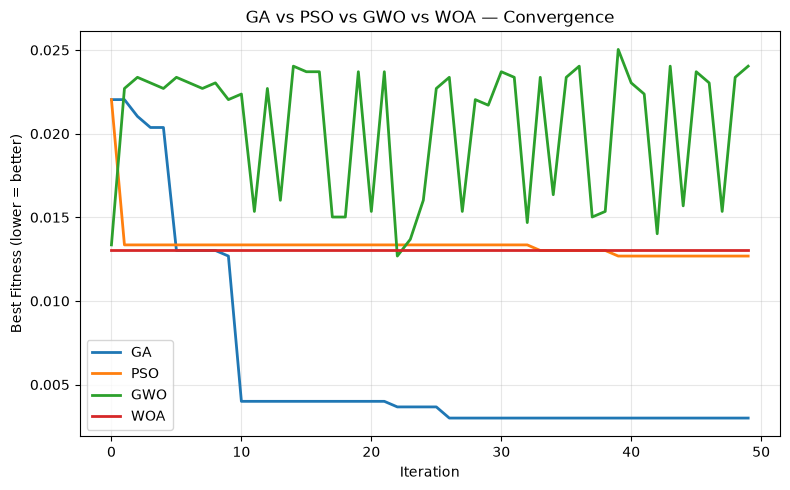

In [8]:
convergence_curves = {}
for algo in ["ga", "pso", "gwo", "woa"]:
    path = os.path.join(results_dir, f"{algo}_convergence.npy")
    if os.path.exists(path):
        convergence_curves[algo.upper()] = np.load(path)

if convergence_curves:
    plot_convergence(convergence_curves, title="GA vs PSO vs GWO vs WOA — Convergence",
                      save_path="../results/convergence_comparison.png")
else:
    print("No convergence data found yet — run the optimizer notebooks first.")

## 4. Feature count comparison

c:\Users\wesal\OneDrive\Desktop\Summer AI Research\Experiments\FeatureSelection-Medical\notebooks\..\utils\plotting.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=counts, palette="viridis")


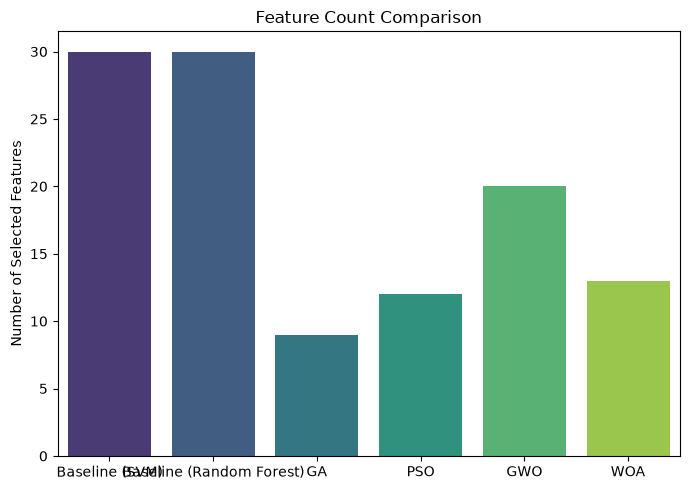

In [9]:
feature_counts = dict(zip(all_results["Algorithm"], all_results["Features"]))
plot_feature_counts(feature_counts, save_path="../results/feature_count_comparison.png")

## 5. Runtime comparison

c:\Users\wesal\OneDrive\Desktop\Summer AI Research\Experiments\FeatureSelection-Medical\notebooks\..\utils\plotting.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=times, palette="magma")


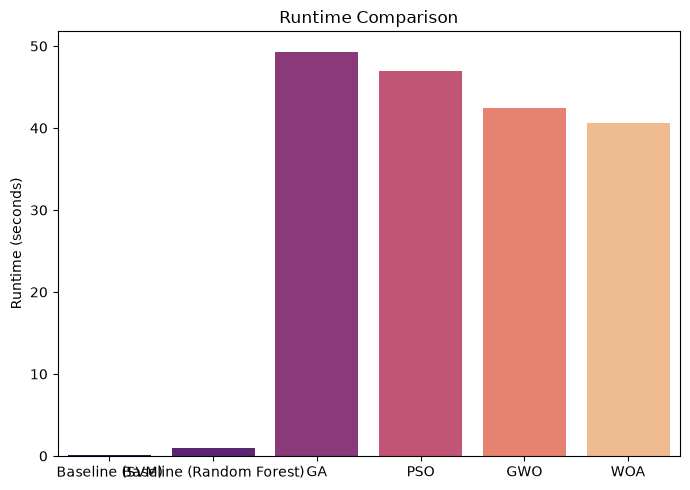

In [10]:
runtimes = dict(zip(all_results["Algorithm"], all_results["Runtime"]))
plot_runtime_comparison(runtimes, save_path="../results/runtime_comparison.png")

## 6. Accuracy / F1 comparison

c:\Users\wesal\OneDrive\Desktop\Summer AI Research\Experiments\FeatureSelection-Medical\notebooks\..\utils\plotting.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Algorithm", y=metric, palette="crest")


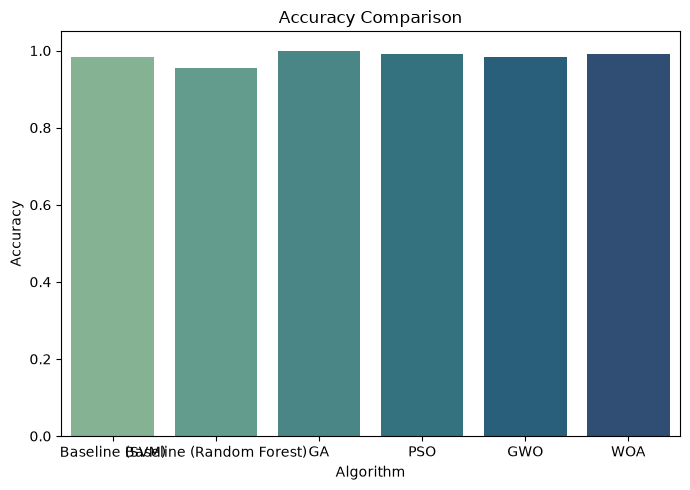

In [11]:
plot_metric_comparison(all_results, metric="Accuracy".lower().capitalize() if False else "Accuracy",
                        save_path="../results/accuracy_comparison.png")

c:\Users\wesal\OneDrive\Desktop\Summer AI Research\Experiments\FeatureSelection-Medical\notebooks\..\utils\plotting.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Algorithm", y=metric, palette="crest")


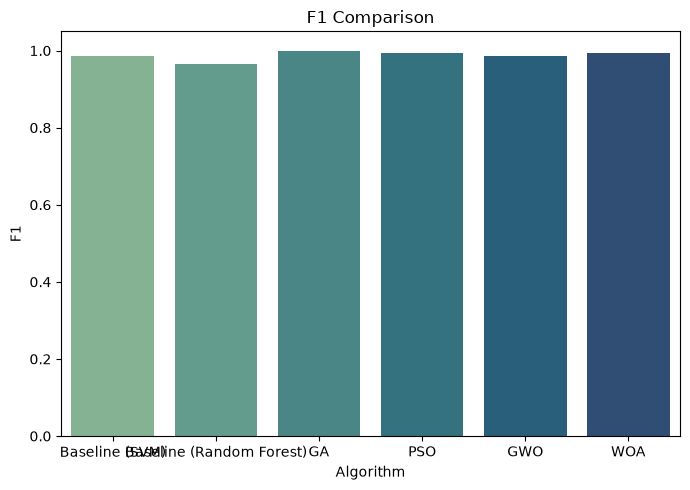

In [12]:
plot_metric_comparison(all_results, metric="F1", save_path="../results/f1_comparison.png")

## 7. Confusion matrices (optional)

Recomputes predictions for the baseline and each optimizer's selected feature
subset, using the saved feature masks (`../results/<algo>_mask.npy`).

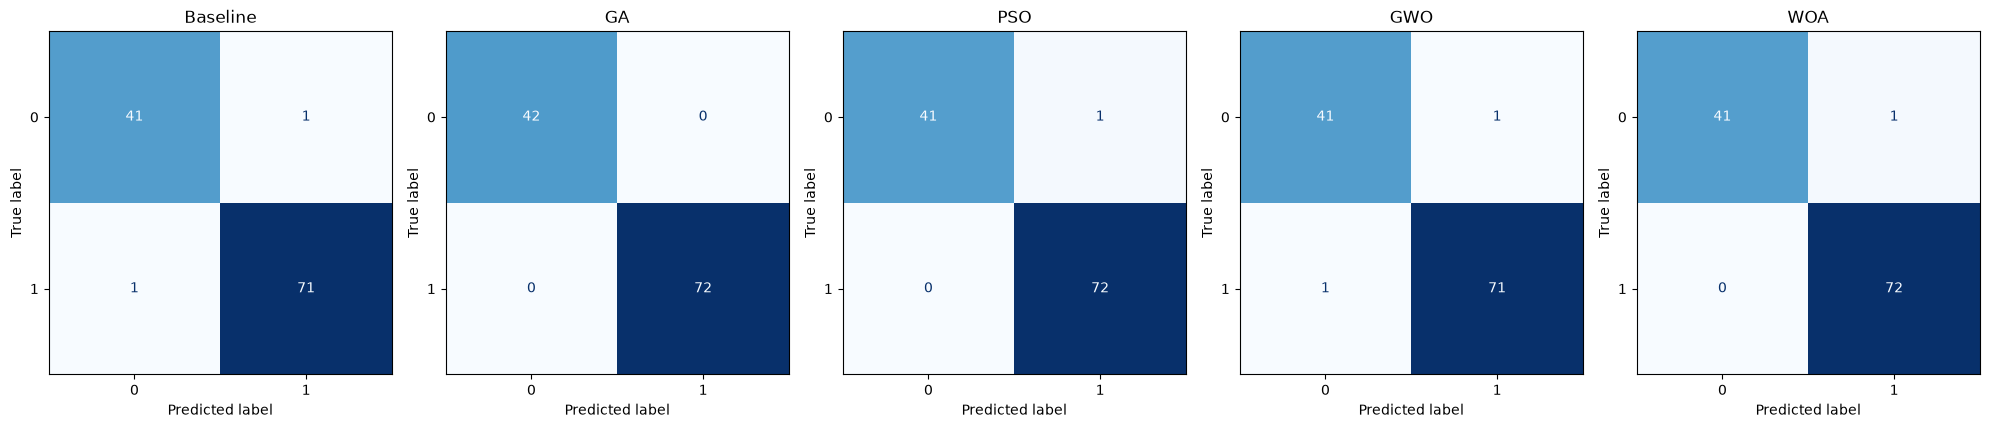

In [13]:
X_train, X_test, y_train, y_test, feature_names = load_processed_data("../datasets")
n_features = X_train.shape[1]

cms = {}

# Baseline: all features
full_mask = np.ones(n_features, dtype=int)
baseline_eval = evaluate_subset(full_mask, X_train, X_test, y_train, y_test, classifier="svm")
cms["Baseline"] = get_confusion_matrix(y_test, baseline_eval["y_pred"])

for algo in ["ga", "pso", "gwo", "woa"]:
    mask_path = os.path.join(results_dir, f"{algo}_mask.npy")
    if os.path.exists(mask_path):
        mask = np.load(mask_path)
        res = evaluate_subset(mask, X_train, X_test, y_train, y_test, classifier="svm")
        cms[algo.upper()] = get_confusion_matrix(y_test, res["y_pred"])

plot_confusion_matrices(cms, save_path="../results/confusion_matrices.png")

## Conclusions

Fill in after running the full pipeline:

- Which optimizer achieved the best accuracy?
- Which optimizer achieved the best accuracy *per feature used* (best trade-off)?
- Did any optimizer beat the baseline while using meaningfully fewer features?
- How did runtime scale across optimizers, and is that trade-off worth it for this
  dataset size?

This comparison is fair because every algorithm (baseline included) was evaluated
with the identical `evaluate_subset()` function, the identical train/test split,
and the identical classifier (SVM) — the only thing that varies is *which features
were selected and how*.